In [10]:
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from typing import Union, Tuple

### Linear models for temperature prediction

In [11]:
temp_data = np.genfromtxt("../Data/EMS/data_temp_ver.csv", delimiter=',')
temp_mean = temp_data.mean()
temp_std = temp_data.std()

temp_data_norm = (temp_data - temp_mean) / temp_std

def create_regresors(data: np.ndarray, n_reg: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create a matrix of regressors for a linear model given a data array and the number of regressors
    :param data: Data array
    :param n_reg: Number of regressors
    :return: Matrix of regressors
    """
    n = data.shape[0]
    X = np.zeros((n - n_reg, n_reg))
    y = np.zeros(n - n_reg)
    for i in range(n - n_reg):
        X[i, :] = data[i:i + n_reg]
        y[i] = data[i + n_reg]
    return X, y

def train_linear_model(X: np.ndarray, y: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Train a linear model given the matrix of regressors and the target variable
    :param X: Matrix of regressors
    :param y: Target variable
    :return: Coefficients of the linear model
    """
    X = np.concatenate((X, np.ones((X.shape[0], 1))), axis=1)
    beta = np.linalg.inv(X.T @ X) @ X.T @ y
    return beta

In [13]:
X, y = create_regresors(temp_data_norm, 6)

params = train_linear_model(X, y)

In [20]:
params

array([nan, nan, nan, nan, nan, nan, nan])

In [19]:
# eval model in one step prediction 

n_pred = 1
preds = []
for i, x in enumerate(X[0:3]):
    y_pred = x @ params
    print(y_pred)
    preds.append(y_pred)
    

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 7 is different from 6)

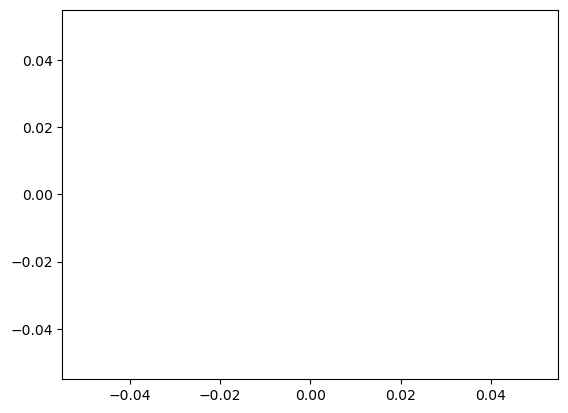

In [17]:
plt.plot(preds)

In [135]:


delay = 6 * 6  # 6 hours in 10 minutes intervals


def get_demand() -> np.ndarray:
    """
    Read the demand data from the csv file and returns it as a numpy array
    :return: Demand data as a numpy array [kWh]
    """

    hourly_demand = np.genfromtxt("../Data/EMS/consumption.csv", delimiter=',')
    s_hourly_demand = hourly_demand.shape
    demand = np.zeros((s_hourly_demand[0], s_hourly_demand[1] * 6))
    for i in range(s_hourly_demand[0]):
        for j in range(s_hourly_demand[1]):
            demand[i, j * 6:(j + 1) * 6] = hourly_demand[i, j]
    demand = demand.flatten()
    return demand


def get_temperatura(season: str = 'ver') -> np.ndarray:
    """
    Read the temperature data from the csv file and returns it as a numpy array

    :param season: 'ver' for summer and 'inv' for winter
    :return: Temperature data as a numpy array
    """
    if season == 'ver':
        file_path = "../Data/EMS/data_temp_ver.csv"
    else:
        file_path = "../Data/EMS/data_temp_inv.csv"
    temperatura = pd.read_csv(file_path)
    temperatura = temperatura.interpolate().values.flatten()
    return temperatura[delay:]


def get_rad(season: str = 'ver') -> np.ndarray:
    """
    Read the radiation data from the csv file and returns it as a numpy array

    :param season: 'ver' for summer and 'inv' for winter
    :return: Radiation data as a numpy array

    """
    if season == 'ver':
        file_path = "../Data/EMS/data_rad_ver.csv"
    else:
        file_path = "../Data/EMS/data_rad_inv.csv"

    rad = pd.read_csv(file_path)
    rad = rad.values.flatten()
    return rad[delay:]


def get_ref() -> np.ndarray:
    """Read the references data from the csv file and returns it as a numpy array"""
    refs = pd.read_csv('../Data/EMS/v_refs.csv')
    refs = refs.values.flatten()
    return refs


def solar_power(rad: Union[float, np.ndarray], temp: Union[float, np.ndarray]) -> Union[float, np.ndarray]:
    """
    Computes the solar power in kW given the radiation in W/m2 and the temperature in C.

    :parameter rad: Radiation in W/m2
    :parameter temp: Temperature in °C
    :return: Solar power in kW

    """
    Pn = 90
    a_fv = -.0045
    Tn = 25
    T_cell = temp + rad / 800 * (Tn - 20)
    return (Pn * rad / 1000.) * (1 + a_fv * (T_cell - Tn))


In [136]:
df = pd.read_csv("../Data/EMS/consumption.csv")
data_rad = df.to_numpy().flatten()
data_rad.max(), data_rad.min()

(19.5145378821083, 3.50158133889136)

In [137]:
p_fv = solar_power(get_rad(), get_temperatura())

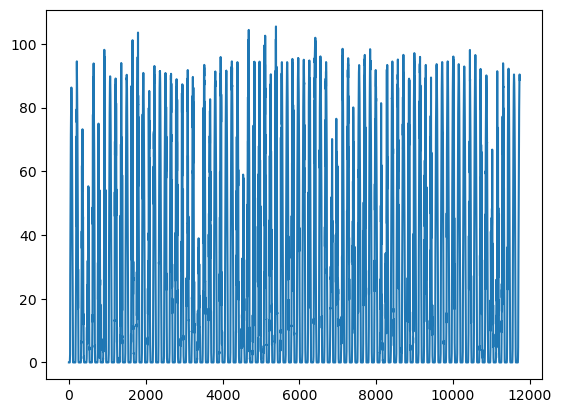

In [138]:
plt.plot(p_fv)

In [162]:
class LSTM_model(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, device = 'cuda'):
        super(LSTM_model, self).__init__()
        self.device = device
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        device = self.device
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        hidden = (h0, c0)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out[:, :, :])
        return out
    
mean = p_fv.mean()
std = p_fv.std()

p_fv = (p_fv - mean) / std

In [183]:
# Creating our dataset class
class Build_Data(Dataset):    
    # Constructor
    def __init__(self, dataset):
        self.x = torch.tensor(dataset, dtype=torch.float32, device='cuda').unsqueeze(-1)
        self.time = torch.tensor(np.linspace(0,1,144), dtype=torch.float32, device='cuda').unsqueeze(-1)
        self.len = self.x.shape[0]//144      
    # Getting the data
    def __getitem__(self, index): 
        d_index = index * 144   
        value = self.x[d_index:d_index+143, :]
        return torch.cat((value, self.time[0:143,:]), dim=-1), self.x[d_index+1:d_index+144,:]    
    # Getting length of the data
    def __len__(self):
        return self.len
    
x_train = p_fv[0:70*144]
x_val = p_fv[70*144:81*144]

# Creating DataLoader object
train_dataset = Build_Data(x_train)
train_loader = DataLoader(dataset = train_dataset, batch_size = 3)

# Creating the model

val_dataset = Build_Data(x_val)
val_loader = DataLoader(dataset = val_dataset, batch_size = 3)


In [184]:
for x, y in train_loader:
    print(x.shape, y.shape)
    break

torch.Size([3, 143, 2]) torch.Size([3, 143, 1])


In [164]:
a = torch.tensor(-p_fv, dtype=torch.float32, device='cuda').unsqueeze(-1)
value = a[0:143, :]
value.shape
time = torch.tensor(np.linspace(0,1,value.shape[0]), dtype=torch.float32, device='cuda').unsqueeze(-1)
value.shape, time.shape
torch.cat((value, time), dim=-1).shape

torch.Size([143, 2])

In [165]:
model = LSTM_model(input_size=2, hidden_size=64, num_layers=2, output_size=1).to('cuda')
epochs = 1000
lr = 0.001
criterion = nn.MSELoss()
optimizer = torch.optim.RAdam(model.parameters(), lr=lr)
iters = 100

for epoch in range(epochs):
    loss = 0
    for x, y in train_loader:
        y_pred = model(x)
        loss += criterion(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        # validation loss
        loss = 0
        for x, y in val_loader:
            y_pred = model(x)
            loss += criterion(y_pred, y)
        print(f'Epoch: {epoch}, Loss: {loss.item()}')

Epoch: 0, Loss: 4.098882675170898
Epoch: 10, Loss: 4.017401695251465
Epoch: 20, Loss: 3.955533981323242
Epoch: 30, Loss: 3.865516185760498
Epoch: 40, Loss: 3.7400145530700684
Epoch: 50, Loss: 3.5551486015319824
Epoch: 60, Loss: 3.257955312728882
Epoch: 70, Loss: 2.734495162963867
Epoch: 80, Loss: 1.8008995056152344
Epoch: 90, Loss: 0.9547927975654602
Epoch: 100, Loss: 0.8588358163833618
Epoch: 110, Loss: 0.6875053644180298
Epoch: 120, Loss: 0.5941118001937866
Epoch: 130, Loss: 0.5001583099365234
Epoch: 140, Loss: 0.4201475977897644
Epoch: 150, Loss: 0.3527393937110901
Epoch: 160, Loss: 0.2943156361579895
Epoch: 170, Loss: 0.2660442888736725
Epoch: 180, Loss: 0.2549707889556885
Epoch: 190, Loss: 0.241342693567276
Epoch: 200, Loss: 0.22924846410751343
Epoch: 210, Loss: 0.21983052790164948
Epoch: 220, Loss: 0.21169042587280273
Epoch: 230, Loss: 0.20514445006847382
Epoch: 240, Loss: 0.19986554980278015
Epoch: 250, Loss: 0.19549717009067535
Epoch: 260, Loss: 0.19159816205501556
Epoch: 270, 

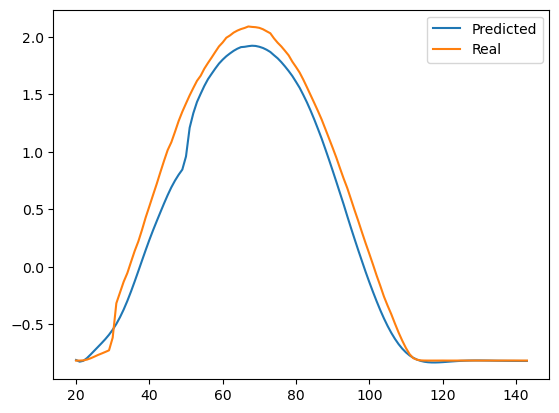

In [189]:
model.eval()
# multistep prediction
h_pred = 20
for x,y in val_dataset:
    y_pred = model(x.unsqueeze(0))
    break
preds = []
time = torch.tensor(np.linspace(0,2,288), dtype=torch.float32, device='cuda').unsqueeze(-1)
for i in range(1,144):
    x0 = x[0:i, 0:1]
    x0 = torch.cat((x0, time[0:i]), dim=-1)
    for j in range(h_pred):
        pred = model(x0.unsqueeze(0))[:,-1, :]
        x0 = torch.cat((x0[:,0:1], pred), dim=0)
        #print(x0.shape, time[0:i+j+1].shape)
        x0 = torch.cat((x0, time[0:i+j+1]), dim=-1)

    preds.append(pred.item())

t = np.arange(h_pred, 144, 1)
plt.plot(t, preds[:144-h_pred], label = 'Predicted')
plt.plot(t, y.squeeze().cpu().numpy()[h_pred-1:], label = 'Real')
plt.legend()

In [187]:
t = np.arange(0, 144, 1)
t.shape

(144,)

In [176]:
x.shape

torch.Size([143, 2])

In [ ]:
# with the first 144 steps, predict the next 144 steps
x0 = x
for i in range(144):
    x0 = 

In [ ]:
y.shape,x.shape

(torch.Size([143, 1]), torch.Size([143, 1]))

In [ ]:
x[0:0,:]

tensor([], device='cuda:0', size=(0, 1))

In [ ]:
model.eval()

for x,y in dataset:
    y_pred = model(x.unsqueeze(0))
    break
# turn everything back to numpy
#y_pred = y_pred.cpu().detach().numpy().flatten()
#y = y.cpu().detach().numpy().flatten()
#x = x.unsqueeze(0).cpu().detach().numpy().flatten()
energy = []
for i in range(144):
    h_pred = 143 - i
    x0 = x[0:i, :]
    preds = []
    for j in range(h_pred):
        y_pred = model(x.unsqueeze(0))[0,-1,:]
        x0 = torch.cat((x0, y_pred.unsqueeze(0)), 0)
        preds.append(y_pred)
    energy.append(torch.tensor(preds).sum().item())


    
    

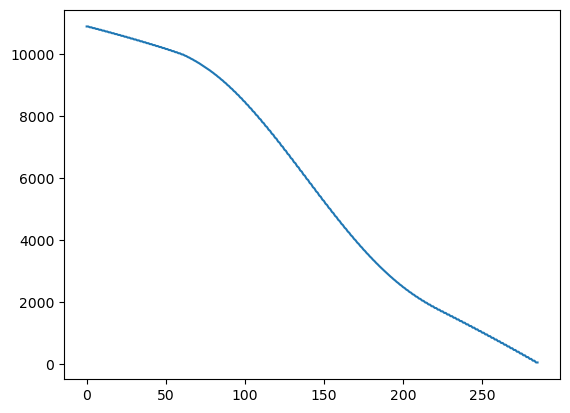

In [170]:
x_ = x.to('cpu').detach().numpy().flatten()*std + mean
results = []
for idx in range(len(x_)):
    results.append(np.sum(x_[idx:]))
plt.plot(results)

In [ ]:
class LSTM_Q_learning(torch.nn.Module):
    def __init__(self, obs_dim, hidden_dim, num_layers):
        super(LSTM_Q_learning, self).__init__()
        self.lstm = nn.LSTM(obs_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

In [193]:
torch.save(model, 'model_p_fv.pth')
torch.save((mean, std), 'mean_std_p_fv.pth')